### PCA & iForest
### Yilin Luo

### Table of Contents

* [1: Introduction](#Section_1)

* [2: Data Preparation](#Section_2)
    * [2.1: Load and Preview Raw Data](#Section_21)
    * [2.2: Clean and Prepare the Dataset](#Section_22)
    
* [3: Feature Engineering](#Section_3)
    * [Feature 1: Ratio of Average Total Payment to DRG Benchmark (ratio_avg_paymentDRG)](#Section_31)
    * [Feature 2: Ratio of Average Total Payment to State Benchmark (ratio_avg_paymentState)](#Section_32)
    * [Feature 3: Ratio of Average Total Payment to City Benchmark (ratio_avg_paymentCity)](#Section_33)
    * [Feature 4: Ratio of Average Total Payment to State-DRG Benchmark (ratio_avg_paymentDRGState)](#Section_34)
    * [Feature 5: Ratio of Average Total Payments to City-DRG Benchmark (ratio_avg_paymentDRGCity)](#Section_35)
    * [Feature 6: Ratio of Average Medicare Payment to DRG Benchmark (ratio_avg_medicare_paymentDRG)](#Section_36)
    * [Feature 7: Ratio of Average Medicare Payment to State Benchmark (ratio_avg_medicare_paymentState)](#Section_37)
    * [Feature 8: Ratio of Average Medicare Payment to City Benchmark (ratio_avg_medicare_paymentCity)](#Section_38)
    * [Feature 9: Ratio of Average Medicare Payment to State-DRG Benchmark (ratio_avg_medicare_paymentDRGState)](#Section_39)
    * [Feature 10: Ratio of Average Medicare Payment to City-DRG Benchmark (ratio_avg_medicare_paymentDRGCity)](#Section_310)
    * [Feature 11: Ratio of Total Discharges to State-DRG Benchmark (ratio_discharges_DRGState)](#Section_311)
    * [Feature 12: Ratio of Total Discharges to City-DRG Benchmark (ratio_discharges_DRGCity)](#Section_312)
    * [Summary of the Created Ratio Features](#Section_313)
    
* [4. Prepare Feature Dataset for Modeling](#Section_4)

* [5. Isolation Forest (iForest)](#Section_5)
    * [Step 1: Build the Model](#Section_51)
    * [Step 2: Determine a Reasonable Threshold for the Model](#Section_52)
    * [Step 3: Descriptive Statistics](#Section_53)
    * [Step 4: Achieve Model Stability by Aggregating Multiple Models](#Section_54)
    * [Summary of the iForest Model](#Section_55)

* [6. PCA Analysis](#Section_6)
    * [Step 1: Build the Model](#Section_61)
    * [Step 2: Determine the Threshold for the Model](#Section_62)
    * [Step 3: Descriptive Statistics](#Section_63)
    * [Summary of the PCA Analysis](#Section_63)

* [7: Comparisons between models ](#Section_7)
    * [Summary of Model Comparison Results ](#Section_71)

### 1. Introduction <a class="anchor" id="Section_1"></a>

In this assignment, we explored advanced unsupervised anomaly detection techniques—Principal Component Analysis (PCA) and Isolation Forest (iForest)—to identify unusual patterns in a healthcare dataset containing engineered ratio-based features reflecting hospital costs, payments, and discharges. Building on prior experience with anomaly detection in financial data, we applied both models to detect potential outliers that may signal abnormal hospital reimbursement practices or data quality issues. We analyzed model outputs through visualizations, statistical summaries, and confusion matrices, and further compared these results with alternative methods like HBOS and ECOD to assess consistency and effectiveness. Our goal was to evaluate how these diverse anomaly detection methods perform on complex, high-dimensional healthcare data and to uncover insights that could guide further investigation into outlier hospitals or practices.

### 2. Data Preparation <a class="anchor" id="Section_2"></a>

### 2.1 Load and Preview Raw Data <a class="anchor" id="Section_21"></a>

In [1]:
#!pip install pyod
#!pip install combo

In [208]:
# Import all required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pyod.utils.data import generate_data
from sklearn.preprocessing import StandardScaler
from pyod.models.iforest import IForest
from pyod.utils.utility import standardizer
from sklearn.model_selection import train_test_split
from pyod.models.combination import aom, moa, average, maximization
from pyod.models.pca import PCA

In [3]:
# Load the dataset
df = pd.read_csv('inpatientCharges.csv')

# Preview the dataset shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (163065, 12)


,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,$32963.07,$5777.24,$4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,$15131.85,$5787.57,$4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,$37560.37,$5434.95,$4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,$13998.28,$5417.56,$4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,$31633.27,$5658.33,$4851.44


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163065 entries, 0 to 163064
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype 
---  ------                                --------------   ----- 
 0   DRG Definition                        163065 non-null  object
 1   Provider Id                           163065 non-null  int64 
 2   Provider Name                         163065 non-null  object
 3   Provider Street Address               163065 non-null  object
 4   Provider City                         163065 non-null  object
 5   Provider State                        163065 non-null  object
 6   Provider Zip Code                     163065 non-null  int64 
 7   Hospital Referral Region Description  163065 non-null  object
 8    Total Discharges                     163065 non-null  int64 
 9    Average Covered Charges              163065 non-null  object
 10   Average Total Payments               163065 non-null  object
 11  Average Medic

### 2.2 Clean and Prepare the Dataset <a class="anchor" id="Section_22"></a>

In [5]:
# Rename columns and drop unused column

df.columns = ['DRG','Provider_Id', 'Provider_Name','Provider_StreetAddress','Provider_City',
               'Provider_State','Provider_Zipcode','Hospital_referral_region_desp',
                'Total_Discharges','Average_Covered_Charges','Average_Total_Payments',
                'Average_Medicare_Payment']
df = df.drop('Average_Covered_Charges',axis=1)

In [6]:
# Distribution plots of average total payments 
df['Average_Total_Payments'].describe()

count       163065
unique      147842
top       $4370.00
freq             9
Name: Average_Total_Payments, dtype: object

In [7]:
# Distribution plots of average medicare payment
df['Average_Medicare_Payment'].describe()

count       163065
unique      150328
top       $4908.00
freq             5
Name: Average_Medicare_Payment, dtype: object

In [8]:
# Change data type and transfer spending amount with dollar sign into numeric
df['DRG'] = df['DRG'].astype('category')
df['Provider_State'] = df['Provider_State'].astype('category')
df['Provider_City'] = df['Provider_City'].astype('category')
df['Provider_Id'] = df['Provider_Id'].astype('category')

# Function to safely strip $ and commas and convert to float
def money_to_float(x):
    if pd.isna(x):
        return None
    # Convert to string first
    x_str = str(x)
    # Remove $ and commas
    x_str = x_str.replace('$', '').replace(',', '')
    try:
        return float(x_str)
    except ValueError:
        return None

# Apply to the relevant columns
df['Average_Total_Payments'] = df['Average_Total_Payments'].apply(money_to_float)
df['Average_Medicare_Payment'] = df['Average_Medicare_Payment'].apply(money_to_float)


In [9]:
df.head()

,DRG,Provider_Id,Provider_Name,Provider_StreetAddress,Provider_City,Provider_State,Provider_Zipcode,Hospital_referral_region_desp,Total_Discharges,Average_Total_Payments,Average_Medicare_Payment
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,5777.24,4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,5787.57,4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,5434.95,4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,5417.56,4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,5658.33,4851.44


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163065 entries, 0 to 163064
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   DRG                            163065 non-null  category
 1   Provider_Id                    163065 non-null  category
 2   Provider_Name                  163065 non-null  object  
 3   Provider_StreetAddress         163065 non-null  object  
 4   Provider_City                  163065 non-null  category
 5   Provider_State                 163065 non-null  category
 6   Provider_Zipcode               163065 non-null  int64   
 7   Hospital_referral_region_desp  163065 non-null  object  
 8   Total_Discharges               163065 non-null  int64   
 9   Average_Total_Payments         163065 non-null  float64 
 10  Average_Medicare_Payment       163065 non-null  float64 
dtypes: category(4), float64(2), int64(2), object(3)
memory usage: 9.9+ MB


### 3. Feature Engineering <a class="anchor" id="Section_3"></a>

To ensure our data is well-prepared for PCA and iForest modeling, we developed new features and refined several from our previous analysis. Although this section does not explicitly require exploratory data analysis (EDA), we performed EDA on each feature to better understand its distribution, detect potential anomalies, and validate its suitability for modeling. This thorough feature engineering process helps ensure that the features used in our models effectively capture significant patterns and potential outliers in hospital payment data.

### Feature 1: Ratio of Average Total Payment to DRG Benchmark (ratio_avg_paymentDRG) <a class="anchor" id="Section_31"></a>

This feature measures how each hospital's average total payment compares to the mean payment for the same DRG across all hospitals. Values > 1 indicate higher-than-average charges, helping to identify providers whose costs significantly exceed typical benchmarks.

In [11]:
# Compute mean average total payment by DRG
benchmark_DRG = (
    df.groupby('DRG', observed=True)['Average_Total_Payments']
    .mean()
    .reset_index()
    .rename(columns={'Average_Total_Payments': 'Mean_Avg_Total_Payment_DRG'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_DRG, on='DRG', how='left')

# Preview
benchmark_DRG.head(3)

,DRG,Mean_Avg_Total_Payment_DRG
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,6960.534004
1,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,6706.276445
2,064 - INTRACRANIAL HEMORRHAGE OR CEREBRAL INFA...,13263.823032


In [13]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_paymentDRG'] = df['Average_Total_Payments'] / (df['Mean_Avg_Total_Payment_DRG'] + epsilon)

In [14]:
df['ratio_avg_paymentDRG'].describe()

count    163065.000000
mean          1.000000
std           0.248259
min           0.464005
25%           0.839686
50%           0.928391
75%           1.085989
max           9.449417
Name: ratio_avg_paymentDRG, dtype: float64

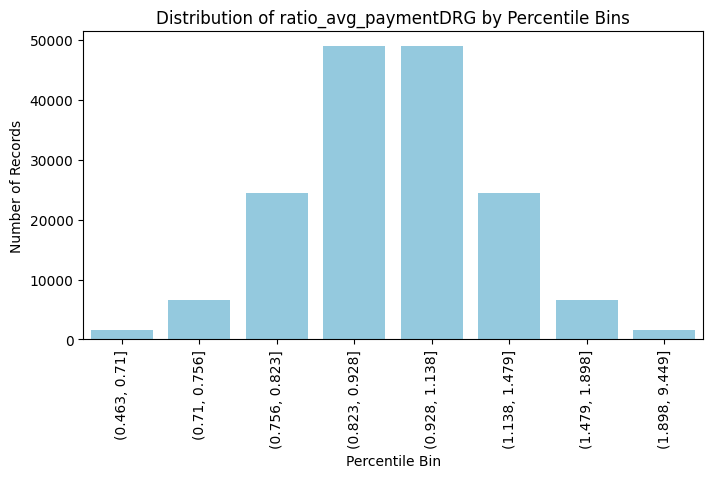

In [15]:
# Define variable
var = 'ratio_avg_paymentDRG'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_paymentDRG by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [16]:
# Detect potential anomalies
threshold = 1.898
df['Anomaly_ratio_avg_paymentDRG'] = (df['ratio_avg_paymentDRG'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_paymentDRG'].sum()}")

Number of anomalies detected: 1626


In [17]:
# Preview potential anomalies
anomalies_f1 = df[df['Anomaly_ratio_avg_paymentDRG'] == 1]
anomalies_f1_table = anomalies_f1 [
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Total_Payments',
        'Mean_Avg_Total_Payment_DRG',
        'ratio_avg_paymentDRG'
    ]
]

# Display first few rows
anomalies_f1_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Total_Payments,Mean_Avg_Total_Payment_DRG,ratio_avg_paymentDRG
104,50334,SALINAS VALLEY MEMORIAL HOSPITAL,CA,SALINAS,450 EAST ROMIE LANE,93901,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,16744.82,6960.534004,2.405680
280,140008,LOYOLA GOTTLIEB MEMORIAL HOSPITAL,IL,MELROSE PARK,701 WEST NORTH AVE,60160,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,18420.56,6960.534004,2.646429
294,140080,RHC ST FRANCIS HOSPITAL,IL,EVANSTON,355 RIDGE AVE,60202,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,17347.00,6960.534004,2.492194


### Feature 2: Ratio of Average Total Payment to State Benchmark (ratio_avg_paymentState) <a class="anchor" id="Section_32"></a>

This feature measures how each hospital’s average total payment compares to the mean payment for all hospitals within the same state, regardless of DRG. Values greater than 1 indicate that a hospital’s costs are higher than the typical average for providers in the same state. This helps detect providers whose pricing may be elevated relative to broader state-level norms.

In [20]:
# Compute mean average total payment by State (Benchmark)
benchmark_State = (
    df.groupby('Provider_State', observed=True)['Average_Total_Payments']
    .mean()
    .reset_index()
    .rename(columns={'Average_Total_Payments': 'Mean_Avg_Total_Payment_State'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_State, on='Provider_State', how='left')

# Preview benchmark
benchmark_State.head(3)

,Provider_State,Mean_Avg_Total_Payment_State
0,AK,14572.391732
1,AL,7568.232149
2,AR,8019.248805


In [21]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_paymentState'] = df['Average_Total_Payments'] / (
    df['Mean_Avg_Total_Payment_State'] + epsilon
)

In [22]:
# View descriptive statistics
print(df['ratio_avg_paymentState'].describe())

count    163065.000000
mean          1.000000
std           0.762004
min           0.235621
25%           0.548603
50%           0.750449
75%           1.171637
max          14.982425
Name: ratio_avg_paymentState, dtype: float64


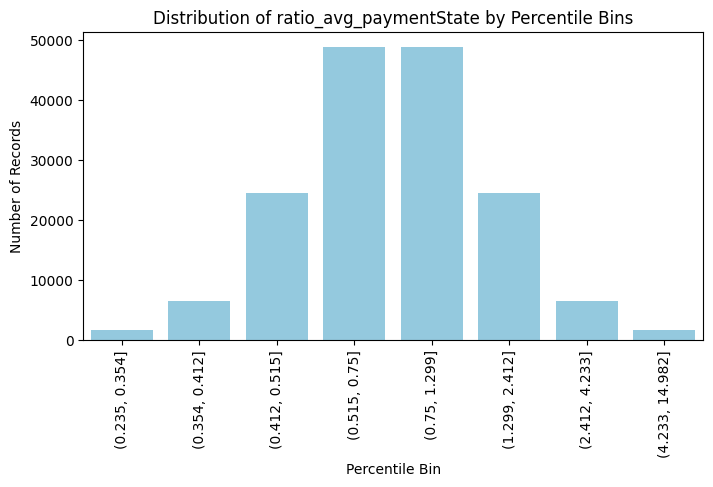

In [23]:
# Define variable for binning
var = 'ratio_avg_paymentState'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_paymentState by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [25]:
# Detect potential anomalies
threshold = 4.233
df['Anomaly_ratio_avg_paymentState'] = (df['ratio_avg_paymentState'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_paymentState'].sum()}")

Number of anomalies detected: 1631


In [26]:
# Preview potential anomalies
anomalies_f2 = df[df['Anomaly_ratio_avg_paymentState'] == 1]
anomalies_f2_table = anomalies_f2[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'Average_Total_Payments',
        'Mean_Avg_Total_Payment_State',
        'ratio_avg_paymentState'
    ]
]

# Display first few rows
anomalies_f2_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,Average_Total_Payments,Mean_Avg_Total_Payment_State,ratio_avg_paymentState
20388,390096,ST JOSEPH MEDICAL CENTER,PA,READING,2500 BERNVILLE ROAD,19605,72797.93,9100.043218,7.999735
39433,10011,ST VINCENT'S EAST,AL,BIRMINGHAM,50 MEDICAL PARK EAST DRIVE,35235,35806.53,7568.232149,4.731162
39434,10023,BAPTIST MEDICAL CENTER SOUTH,AL,MONTGOMERY,2105 EAST SOUTH BOULEVARD,36116,34607.95,7568.232149,4.572792


### Feature 3: Ratio of Average Total Payment to City Benchmark (ratio_avg_paymentCity) <a class="anchor" id="Section_33"></a>

This feature measures how each hospital’s average total payment compares to the mean payment for all hospitals within the same city, regardless of DRG. Values greater than 1 indicate that a hospital’s costs are higher than the typical average for providers in the same city. This helps identify hospitals whose charges stand out locally, potentially signaling unusual billing practices or cost structures.

In [27]:
# Compute mean average total payment by City (Benchmark)
benchmark_City = (
    df.groupby('Provider_City', observed=True)['Average_Total_Payments']
    .mean()
    .reset_index()
    .rename(columns={'Average_Total_Payments': 'Mean_Avg_Total_Payment_City'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_City, on='Provider_City', how='left')

# Preview benchmark table
benchmark_City.head(3)

,Provider_City,Mean_Avg_Total_Payment_City
0,ABBEVILLE,6663.217222
1,ABERDEEN,9327.920561
2,ABILENE,8994.949539


In [28]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_paymentCity'] = df['Average_Total_Payments'] / (
    df['Mean_Avg_Total_Payment_City'] + epsilon
)

In [29]:
# View descriptive statistics
print(df['ratio_avg_paymentCity'].describe())

count    163065.000000
mean          1.000000
std           0.707201
min           0.216719
25%           0.569499
50%           0.773642
75%           1.181530
max          13.851871
Name: ratio_avg_paymentCity, dtype: float64


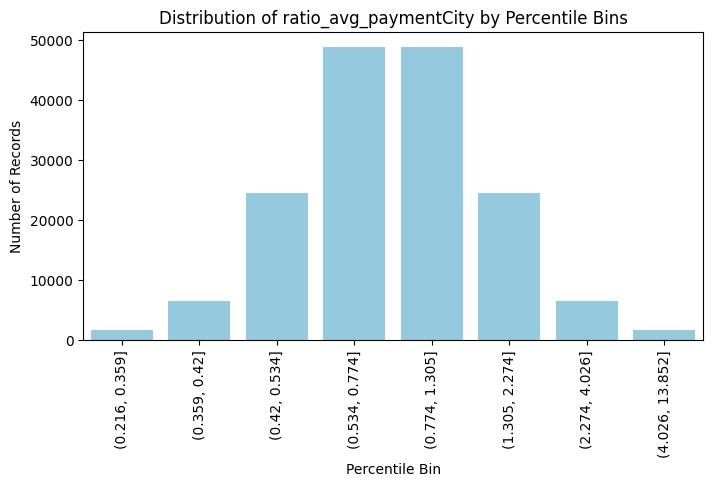

In [30]:
# Define variable for binning
var = 'ratio_avg_paymentCity'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_paymentCity by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [31]:
# Detect potential anomalies
threshold = 4.026
df['Anomaly_ratio_avg_paymentCity'] = (df['ratio_avg_paymentCity'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_paymentCity'].sum()}")


Number of anomalies detected: 1634


In [32]:
# Preview potential anomalies
anomalies_f3 = df[df['Anomaly_ratio_avg_paymentCity'] == 1]
anomalies_f3_table = anomalies_f3[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'Average_Total_Payments',
        'Mean_Avg_Total_Payment_City',
        'ratio_avg_paymentCity'
    ]
]

# Display first few rows
anomalies_f3_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,Average_Total_Payments,Mean_Avg_Total_Payment_City,ratio_avg_paymentCity
20388,390096,ST JOSEPH MEDICAL CENTER,PA,READING,2500 BERNVILLE ROAD,19605,72797.93,10861.472102,6.702400
38923,220008,STURDY MEMORIAL HOSPITAL,MA,ATTLEBORO,211 PARK STREET,2703,41482.09,9654.181159,4.296800
39437,10033,UNIVERSITY OF ALABAMA HOSPITAL,AL,BIRMINGHAM,619 SOUTH 19TH STREET,35233,42550.21,9121.924133,4.664609


### Feature 4: Ratio of Average Total Payment to State-DRG Benchmark (ratio_avg_paymentDRGState) <a class="anchor" id="Section_34"></a>

This feature measures how each hospital’s average total payment compares to the mean payment for the same DRG within the same state. Values greater than 1 indicate that a hospital charges more than typical providers in the same state for that specific procedure, helping identify localized pricing outliers relative to state-level norms for each DRG.

In [35]:
# Compute mean average total payment by State and DRG (Benchmark)
benchmark_DRG_State = (
    df.groupby(['Provider_State', 'DRG'], observed=True)['Average_Total_Payments']
    .mean()
    .reset_index()
    .rename(columns={'Average_Total_Payments': 'Mean_Avg_Total_Payment_DRGState'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_DRG_State,
    on=['Provider_State', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_DRG_State.head(3)

,Provider_State,DRG,Mean_Avg_Total_Payment_DRGState
0,AK,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,8401.95
1,AK,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,8799.00
2,AK,064 - INTRACRANIAL HEMORRHAGE OR CEREBRAL INFA...,21608.01


In [36]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_paymentDRGState'] = df['Average_Total_Payments'] / (
    df['Mean_Avg_Total_Payment_DRGState'] + epsilon
)

In [37]:
# View descriptive statistics
print(df['ratio_avg_paymentDRGState'].describe())

count    163065.000000
mean          1.000000
std           0.195274
min           0.384805
25%           0.880824
50%           0.956830
75%           1.064688
max           7.857934
Name: ratio_avg_paymentDRGState, dtype: float64


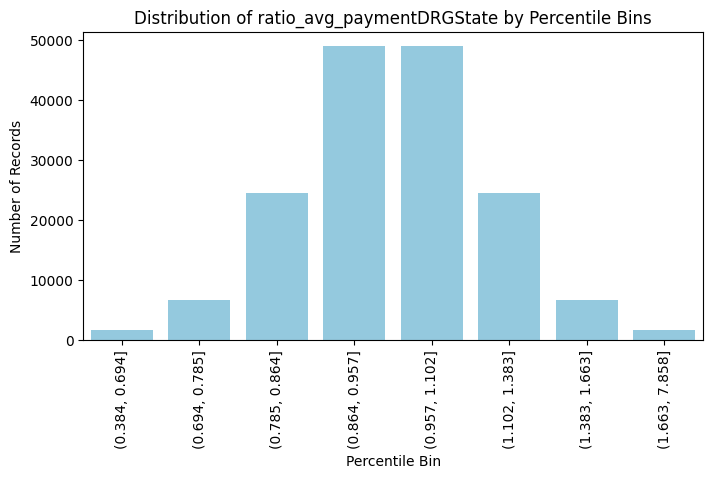

In [38]:
# Define variable for binning
var = 'ratio_avg_paymentDRGState'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_paymentDRGState by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [39]:
# Detect potential anomalies
threshold = 1.663
df['Anomaly_ratio_avg_paymentDRGState'] = (df['ratio_avg_paymentDRGState'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_paymentDRGState'].sum()}")

Number of anomalies detected: 1627


In [40]:
# Preview potential anomalies
anomalies_f4 = df[df['Anomaly_ratio_avg_paymentDRGState'] == 1]
anomalies_f4_table = anomalies_f4[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Total_Payments',
        'Mean_Avg_Total_Payment_DRGState',
        'ratio_avg_paymentDRGState'
    ]
]

# Display first few rows
anomalies_f4_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Total_Payments,Mean_Avg_Total_Payment_DRGState,ratio_avg_paymentDRGState
104,50334,SALINAS VALLEY MEMORIAL HOSPITAL,CA,SALINAS,450 EAST ROMIE LANE,93901,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,16744.82,8387.932687,1.996299
280,140008,LOYOLA GOTTLIEB MEMORIAL HOSPITAL,IL,MELROSE PARK,701 WEST NORTH AVE,60160,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,18420.56,7376.789808,2.497097
294,140080,RHC ST FRANCIS HOSPITAL,IL,EVANSTON,355 RIDGE AVE,60202,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,17347.00,7376.789808,2.351565


### Feature 5: Ratio of Average Total Payments to City-DRG Benchmark (ratio_avg_paymentDRGCity) <a class="anchor" id="Section_35"></a>

This feature measures how each hospital's average total payment compares to the mean payment for the same DRG within the same city. Values > 1 indicate that a hospital charges more than its local peers for the same procedures, helping identify potential localized anomalies in hospital pricing behavior.

In [41]:
# Compute mean average total payment by City and DRG (Benchmark)
benchmark_DRG_City = (
    df.groupby(['Provider_City', 'DRG'], observed=True)['Average_Total_Payments']
    .mean()
    .reset_index()
    .rename(columns={'Average_Total_Payments': 'Mean_Avg_Total_Payment_DRGCity'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_DRG_City,
    on=['Provider_City', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_DRG_City.head(3)

,Provider_City,DRG,Mean_Avg_Total_Payment_DRGCity
0,ABBEVILLE,178 - RESPIRATORY INFECTIONS & INFLAMMATIONS W CC,8770.58
1,ABBEVILLE,192 - CHRONIC OBSTRUCTIVE PULMONARY DISEASE W/...,5007.73
2,ABBEVILLE,194 - SIMPLE PNEUMONIA & PLEURISY W CC,6397.16


In [44]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_paymentDRGCity'] = df['Average_Total_Payments'] / (
    df['Mean_Avg_Total_Payment_DRGCity'] + epsilon
)

In [46]:
# View descriptive statistics
print(df['ratio_avg_paymentDRGCity'].describe())

count    163065.000000
mean          1.000000
std           0.107658
min           0.238195
25%           0.982486
50%           1.000000
75%           1.000000
max           3.753099
Name: ratio_avg_paymentDRGCity, dtype: float64


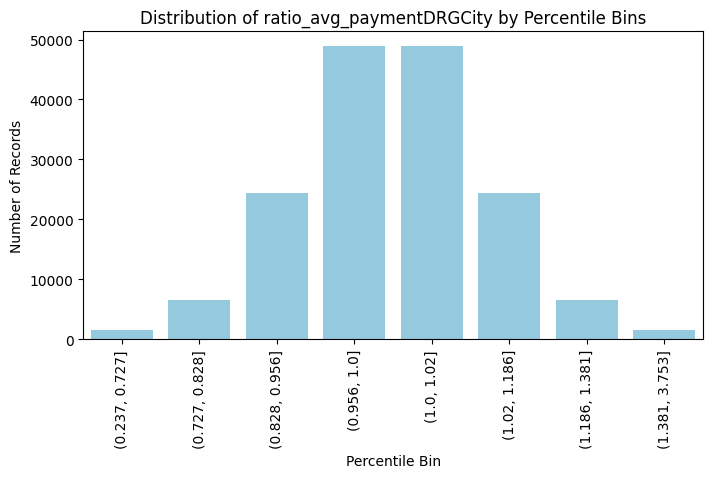

In [47]:
# Define variable for binning
var = 'ratio_avg_paymentDRGCity'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_paymentDRGCity by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [48]:
# Detect potential anomalies
threshold = 1.381
df['Anomaly_ratio_avg_paymentDRGCity'] = (df['ratio_avg_paymentDRGCity'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_paymentDRGCity'].sum()}")

Number of anomalies detected: 1626


In [49]:
# Preview potential anomalies
anomalies_f5 = df[df['Anomaly_ratio_avg_paymentDRGCity'] == 1]
anomalies_f5_table = anomalies_f5[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Total_Payments',
        'Mean_Avg_Total_Payment_DRGCity',
        'ratio_avg_paymentDRGCity'
    ]
]

# Display first few rows
anomalies_f5_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Total_Payments,Mean_Avg_Total_Payment_DRGCity,ratio_avg_paymentDRGCity
245,110010,EMORY UNIVERSITY HOSPITAL,GA,ATLANTA,"1364 CLIFTON ROAD, NE",30322,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,9719.03,6898.576667,1.408846
294,140080,RHC ST FRANCIS HOSPITAL,IL,EVANSTON,355 RIDGE AVE,60202,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,17347.00,12472.530000,1.390816
347,150056,INDIANA UNIVERSITY HEALTH,IN,INDIANAPOLIS,1701 N SENATE BLVD,46206,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,9764.93,6730.840000,1.450774


### Feature 6: Ratio of Average Medicare Payment to DRG Benchmark (ratio_avg_medicare_paymentDRG) <a class="anchor" id="Section_36"></a>

This feature measures how each hospital’s average Medicare payment compares to the mean Medicare payment for the same DRG across all hospitals nationwide. Values greater than 1 indicate that a hospital receives higher-than-average Medicare reimbursements for a particular procedure, helping to identify providers whose Medicare billing patterns may be unusually high compared to national norms.

In [55]:
# Compute mean average Medicare payment by DRG (Benchmark)
benchmark_medicare_DRG = (
    df.groupby('DRG', observed=True)['Average_Medicare_Payment']
    .mean()
    .reset_index()
    .rename(columns={'Average_Medicare_Payment': 'Mean_Avg_Medicare_Payment_DRG'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_medicare_DRG, on='DRG', how='left')

# Preview benchmark table
benchmark_medicare_DRG.head(3)

,DRG,Mean_Avg_Medicare_Payment_DRG
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,5555.837525
1,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,5701.676570
2,064 - INTRACRANIAL HEMORRHAGE OR CEREBRAL INFA...,12112.849445


In [56]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_medicare_paymentDRG'] = df['Average_Medicare_Payment'] / (
    df['Mean_Avg_Medicare_Payment_DRG'] + epsilon
)

In [58]:
# View descriptive statistics
print(df['ratio_avg_medicare_paymentDRG'].describe())

count    163065.000000
mean          1.000000
std           0.281375
min           0.337408
25%           0.820838
50%           0.917180
75%           1.090344
max           7.672359
Name: ratio_avg_medicare_paymentDRG, dtype: float64


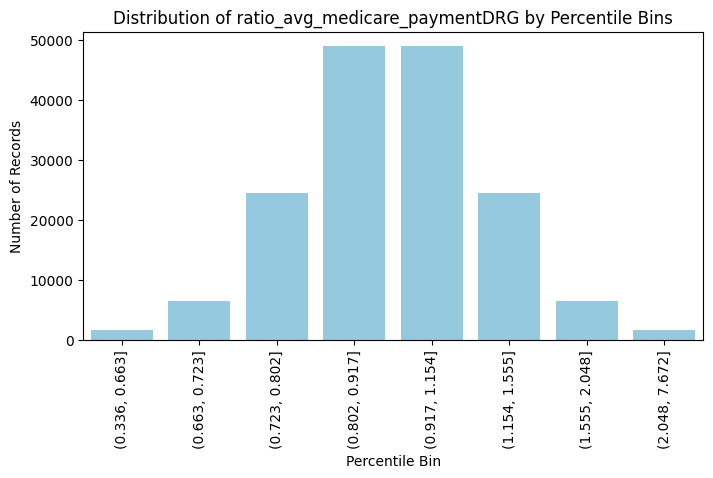

In [59]:
# Define variable for binning
var = 'ratio_avg_medicare_paymentDRG'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_medicare_paymentDRG by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [60]:
# Detect potential anomalies
threshold = 2.048
df['Anomaly_ratio_avg_medicare_paymentDRG'] = (df['ratio_avg_medicare_paymentDRG'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_medicare_paymentDRG'].sum()}")

Number of anomalies detected: 1636


In [61]:
# Preview potential anomalies
anomalies_f6 = df[df['Anomaly_ratio_avg_medicare_paymentDRG'] == 1]
anomalies_f6_table = anomalies_f6[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Medicare_Payment',
        'Mean_Avg_Medicare_Payment_DRG',
        'ratio_avg_medicare_paymentDRG'
    ]
]

# Display first few rows
anomalies_f6_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Medicare_Payment,Mean_Avg_Medicare_Payment_DRG,ratio_avg_medicare_paymentDRG
114,50441,STANFORD HOSPITAL,CA,STANFORD,300 PASTEUR DRIVE,94305,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,11483.40,5555.837525,2.066907
449,210009,"JOHNS HOPKINS HOSPITAL, THE",MD,BALTIMORE,600 NORTH WOLFE STREET,21287,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,11891.22,5555.837525,2.140311
456,210029,JOHNS HOPKINS BAYVIEW MEDICAL CENTER,MD,BALTIMORE,4940 EASTERN AVENUE,21224,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,15855.18,5555.837525,2.853788


### Feature 7: Ratio of Average Medicare Payment to State Benchmark (ratio_avg_medicare_paymentState) <a class="anchor" id="Section_37"></a>

This feature measures how each hospital’s average Medicare payment compares to the mean Medicare payment for all hospitals within the same state, regardless of DRG. Values greater than 1 indicate that a hospital receives higher Medicare reimbursements than typical providers in the same state. This helps identify hospitals with potentially elevated Medicare billing patterns relative to broader state norms.

In [64]:
# Compute mean average Medicare payment by State (Benchmark)
benchmark_medicare_State = (
    df.groupby('Provider_State', observed=True)['Average_Medicare_Payment']
    .mean()
    .reset_index()
    .rename(columns={'Average_Medicare_Payment': 'Mean_Avg_Medicare_Payment_State'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_medicare_State, on='Provider_State', how='left')

# Preview benchmark table
benchmark_medicare_State.head(3)

,Provider_State,Mean_Avg_Medicare_Payment_State
0,AK,12958.969437
1,AL,6418.007120
2,AR,6919.720832


In [65]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_medicare_paymentState'] = df['Average_Medicare_Payment'] / (
    df['Mean_Avg_Medicare_Payment_State'] + epsilon
)

In [66]:
# View descriptive statistics
print(df['ratio_avg_medicare_paymentState'].describe())

count    163065.000000
mean          1.000000
std           0.827851
min           0.171790
25%           0.502919
50%           0.733641
75%           1.200177
max          17.446028
Name: ratio_avg_medicare_paymentState, dtype: float64


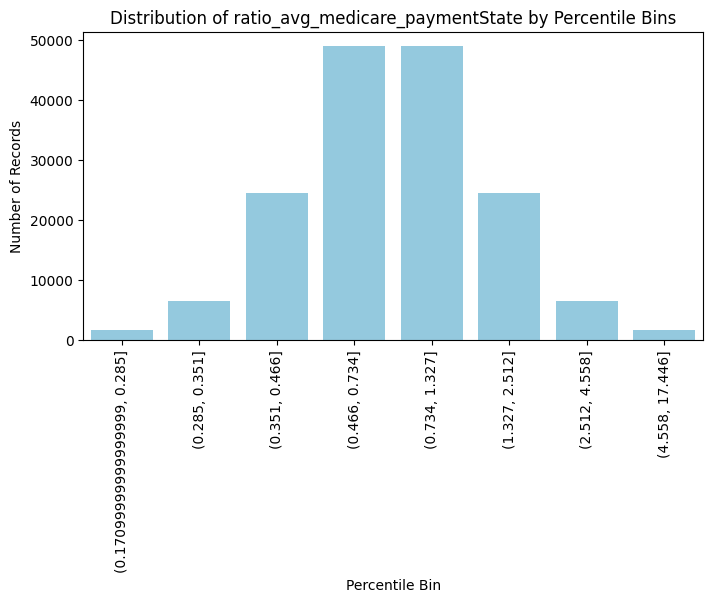

In [67]:
# Define variable for binning
var = 'ratio_avg_medicare_paymentState'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_medicare_paymentState by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [68]:
# Detect potential anomalies
threshold = 4.558
df['Anomaly_ratio_avg_medicare_paymentState'] = (df['ratio_avg_medicare_paymentState'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_medicare_paymentState'].sum()}")


Number of anomalies detected: 1634


In [69]:
# Preview potential anomalies
anomalies_f7 = df[df['Anomaly_ratio_avg_medicare_paymentState'] == 1]
anomalies_f7_table = anomalies_f7[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'Average_Medicare_Payment',
        'Mean_Avg_Medicare_Payment_State',
        'ratio_avg_medicare_paymentState'
    ]
]

# Display first few rows
anomalies_f7_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,Average_Medicare_Payment,Mean_Avg_Medicare_Payment_State,ratio_avg_medicare_paymentState
39433,10011,ST VINCENT'S EAST,AL,BIRMINGHAM,50 MEDICAL PARK EAST DRIVE,35235,29393.46,6418.00712,4.579842
39434,10023,BAPTIST MEDICAL CENTER SOUTH,AL,MONTGOMERY,2105 EAST SOUTH BOULEVARD,36116,32496.47,6418.00712,5.063327
39437,10033,UNIVERSITY OF ALABAMA HOSPITAL,AL,BIRMINGHAM,619 SOUTH 19TH STREET,35233,40777.57,6418.00712,6.353619


### Feature 8: Ratio of Average Medicare Payment to City Benchmark (ratio_avg_medicare_paymentCity) <a class="anchor" id="Section_38"></a>

This feature measures how each hospital’s average Medicare payment compares to the mean Medicare payment for all hospitals within the same city, regardless of DRG. Values greater than 1 indicate that a hospital receives higher Medicare reimbursements than its local peers, helping identify hospitals with potentially unusual Medicare billing patterns relative to the local market.

In [70]:
# Compute mean average Medicare payment by City (Benchmark)
benchmark_medicare_City = (
    df.groupby('Provider_City', observed=True)['Average_Medicare_Payment']
    .mean()
    .reset_index()
    .rename(columns={'Average_Medicare_Payment': 'Mean_Avg_Medicare_Payment_City'})
)

# Merge benchmark back to the main data
df = df.merge(benchmark_medicare_City, on='Provider_City', how='left')

# Preview benchmark table
benchmark_medicare_City.head(3)

,Provider_City,Mean_Avg_Medicare_Payment_City
0,ABBEVILLE,5936.423333
1,ABERDEEN,8338.016168
2,ABILENE,7558.788618


In [71]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_medicare_paymentCity'] = df['Average_Medicare_Payment'] / (
    df['Mean_Avg_Medicare_Payment_City'] + epsilon
)

In [72]:
# View descriptive statistics
print(df['ratio_avg_medicare_paymentCity'].describe())

count    163065.000000
mean          1.000000
std           0.769602
min           0.172029
25%           0.524569
50%           0.755293
75%           1.208660
max          15.692215
Name: ratio_avg_medicare_paymentCity, dtype: float64


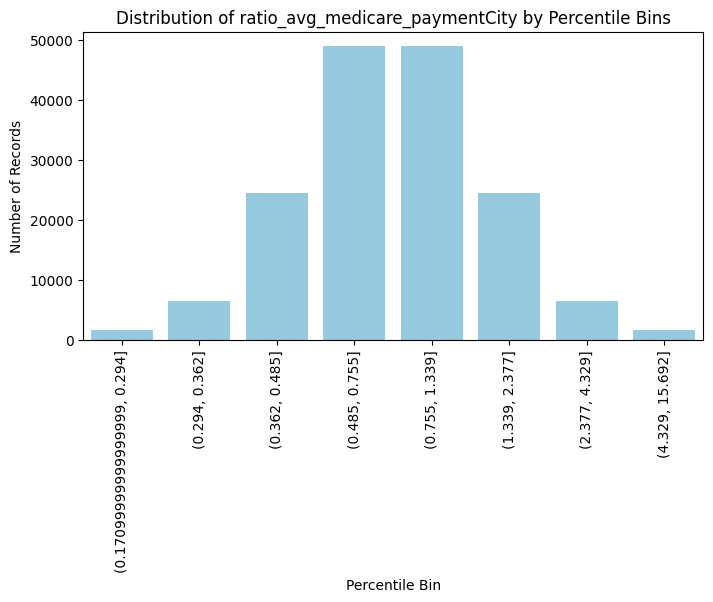

In [73]:
# Define variable for binning
var = 'ratio_avg_medicare_paymentCity'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_medicare_paymentCity by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [74]:
# Detect potential anomalies
threshold = 4.329
df['Anomaly_ratio_avg_medicare_paymentCity'] = (df['ratio_avg_medicare_paymentCity'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_medicare_paymentCity'].sum()}")


Number of anomalies detected: 1629


In [75]:
# Preview potential anomalies
anomalies_f8 = df[df['Anomaly_ratio_avg_medicare_paymentCity'] == 1]
anomalies_f8_table = anomalies_f8[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'Average_Medicare_Payment',
        'Mean_Avg_Medicare_Payment_City',
        'ratio_avg_medicare_paymentCity'
    ]
]

# Display first few rows
anomalies_f8_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,Average_Medicare_Payment,Mean_Avg_Medicare_Payment_City,ratio_avg_medicare_paymentCity
39437,10033,UNIVERSITY OF ALABAMA HOSPITAL,AL,BIRMINGHAM,619 SOUTH 19TH STREET,35233,40777.57,7705.477657,5.292024
39438,10039,HUNTSVILLE HOSPITAL,AL,HUNTSVILLE,101 SIVLEY RD,35801,30855.15,6869.115707,4.491866
39443,10078,NORTHEAST ALABAMA REGIONAL MED CENTER,AL,ANNISTON,400 EAST 10TH STREET,36207,27583.46,6055.669366,4.554981


### Feature 9: Ratio of Average Medicare Payment to State-DRG Benchmark (ratio_avg_medicare_paymentDRGState) <a class="anchor" id="Section_39"></a>

This feature measures how each hospital’s average Medicare payment compares to the mean Medicare payment for the same DRG within the same state. Values greater than 1 indicate that a hospital receives higher reimbursements than other providers in the same state for that specific procedure, helping identify localized anomalies in Medicare billing practices.

In [76]:
# Compute mean average Medicare payment by State and DRG (Benchmark)
benchmark_medicare_DRG_State = (
    df.groupby(['Provider_State', 'DRG'], observed=True)['Average_Medicare_Payment']
    .mean()
    .reset_index()
    .rename(columns={'Average_Medicare_Payment': 'Mean_Avg_Medicare_Payment_DRGState'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_medicare_DRG_State,
    on=['Provider_State', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_medicare_DRG_State.head(3)


,Provider_State,DRG,Mean_Avg_Medicare_Payment_DRGState
0,AK,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,6413.780
1,AK,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,8081.540
2,AK,064 - INTRACRANIAL HEMORRHAGE OR CEREBRAL INFA...,20555.255


In [77]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_medicare_paymentDRGState'] = df['Average_Medicare_Payment'] / (
    df['Mean_Avg_Medicare_Payment_DRGState'] + epsilon
)

In [78]:
# View descriptive statistics
print(df['ratio_avg_medicare_paymentDRGState'].describe())

count    163065.000000
mean          1.000000
std           0.215091
min           0.339831
25%           0.868395
50%           0.954250
75%           1.071483
max           5.174415
Name: ratio_avg_medicare_paymentDRGState, dtype: float64


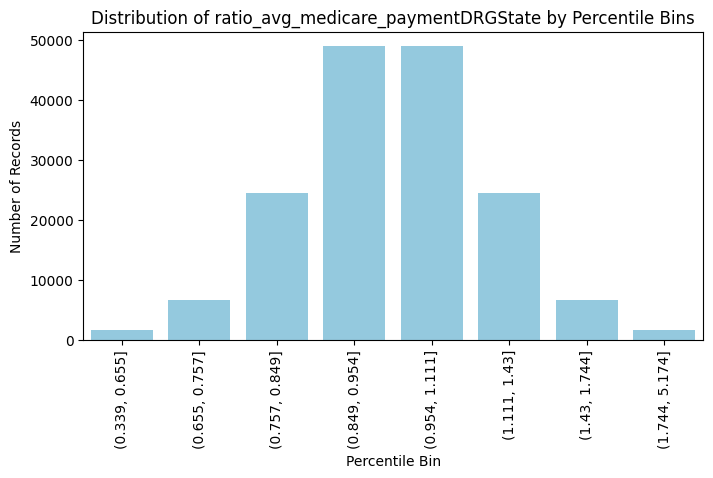

In [79]:
# Define variable for binning
var = 'ratio_avg_medicare_paymentDRGState'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_medicare_paymentDRGState by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [80]:
# Detect potential anomalies
threshold = 1.744
df['Anomaly_ratio_avg_medicare_paymentDRGState'] = (df['ratio_avg_medicare_paymentDRGState'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_medicare_paymentDRGState'].sum()}")


Number of anomalies detected: 1632


In [81]:
# Preview potential anomalies
anomalies_f9 = df[df['Anomaly_ratio_avg_medicare_paymentDRGState'] == 1]
anomalies_f9_table = anomalies_f9[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Medicare_Payment',
        'Mean_Avg_Medicare_Payment_DRGState',
        'ratio_avg_medicare_paymentDRGState'
    ]
]

# Display first few rows
anomalies_f9_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Medicare_Payment,Mean_Avg_Medicare_Payment_DRGState,ratio_avg_medicare_paymentDRGState
456,210029,JOHNS HOPKINS BAYVIEW MEDICAL CENTER,MD,BALTIMORE,4940 EASTERN AVENUE,21224,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,15855.18,8015.386190,1.978093
690,330195,LONG ISLAND JEWISH MEDICAL CENTER,NY,NEW HYDE PARK,270 - 05 76TH AVENUE,11040,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,13280.54,6796.218043,1.954107
1172,50276,CONTRA COSTA REGIONAL MEDICAL CENTER,CA,MARTINEZ,2500 ALHAMBRA AVE,94553,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,18363.08,7506.485256,2.446295


### Feature 10: Ratio of Average Medicare Payment to City-DRG Benchmark (ratio_avg_medicare_paymentDRGCity) <a class="anchor" id="Section_310"></a>

This feature measures how each hospital’s average Medicare payment compares to the mean Medicare payment for the same DRG within the same city. Values greater than 1 indicate that a hospital receives higher reimbursements than other providers in the same city for that specific procedure. This helps identify hospitals whose Medicare billing patterns are unusually high relative to their immediate local market.

In [82]:
# Compute mean average Medicare payment by City and DRG (Benchmark)
benchmark_medicare_DRG_City = (
    df.groupby(['Provider_City', 'DRG'], observed=True)['Average_Medicare_Payment']
    .mean()
    .reset_index()
    .rename(columns={'Average_Medicare_Payment': 'Mean_Avg_Medicare_Payment_DRGCity'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_medicare_DRG_City,
    on=['Provider_City', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_medicare_DRG_City.head(3)

,Provider_City,DRG,Mean_Avg_Medicare_Payment_DRGCity
0,ABBEVILLE,178 - RESPIRATORY INFECTIONS & INFLAMMATIONS W CC,8071.08
1,ABBEVILLE,192 - CHRONIC OBSTRUCTIVE PULMONARY DISEASE W/...,4318.73
2,ABBEVILLE,194 - SIMPLE PNEUMONIA & PLEURISY W CC,5298.79


In [83]:
# Calculate raw ratio
epsilon = 1e-5  # to avoid division by zero
df['ratio_avg_medicare_paymentDRGCity'] = df['Average_Medicare_Payment'] / (
    df['Mean_Avg_Medicare_Payment_DRGCity'] + epsilon
)

In [84]:
# View descriptive statistics
print(df['ratio_avg_medicare_paymentDRGCity'].describe())

count    163065.000000
mean          1.000000
std           0.119402
min           0.261737
25%           0.979755
50%           1.000000
75%           1.000000
max           3.846861
Name: ratio_avg_medicare_paymentDRGCity, dtype: float64


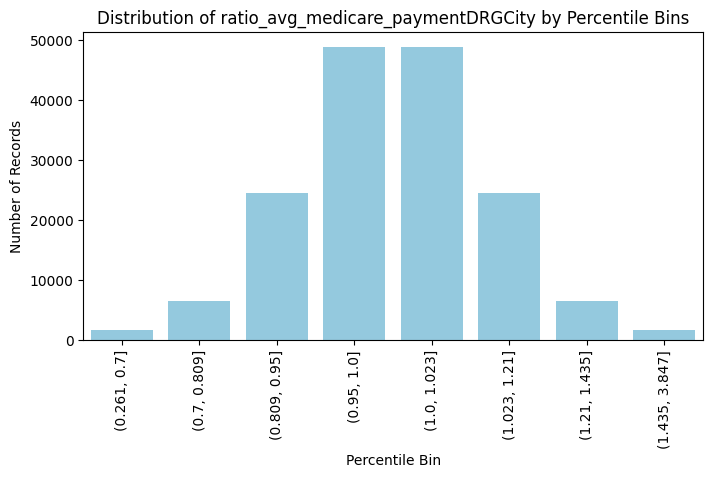

In [85]:
# Define variable for binning
var = 'ratio_avg_medicare_paymentDRGCity'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_avg_medicare_paymentDRGCity by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [86]:
# Detect potential anomalies
threshold = 1.435
df['Anomaly_ratio_avg_medicare_paymentDRGCity'] = (df['ratio_avg_medicare_paymentDRGCity'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_avg_medicare_paymentDRGCity'].sum()}")


Number of anomalies detected: 1625


In [87]:
# Preview potential anomalies
anomalies_f10 = df[df['Anomaly_ratio_avg_medicare_paymentDRGCity'] == 1]
anomalies_f10_table = anomalies_f10[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Average_Medicare_Payment',
        'Mean_Avg_Medicare_Payment_DRGCity',
        'ratio_avg_medicare_paymentDRGCity'
    ]
]

# Display first few rows
anomalies_f10_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Average_Medicare_Payment,Mean_Avg_Medicare_Payment_DRGCity,ratio_avg_medicare_paymentDRGCity
456,210029,JOHNS HOPKINS BAYVIEW MEDICAL CENTER,MD,BALTIMORE,4940 EASTERN AVENUE,21224,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,15855.18,9581.675714,1.654740
755,360059,METRO HEALTH MEDICAL CENTER,OH,CLEVELAND,2500 METROHEALTH DRIVE,44109,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,8660.25,5994.046000,1.444809
928,450068,MEMORIAL HERMANN TEXAS MEDICAL CENTER,TX,HOUSTON,6411 FANNIN,77030,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,9097.62,6113.931667,1.488015


### Feature 11: Ratio of Total Discharges to State-DRG Benchmark (ratio_discharges_DRGState) <a class="anchor" id="Section_311"></a>

This feature measures how each hospital’s total discharges for a specific DRG compare to the average number of discharges for that same DRG within the same state. Values greater than 1 indicate that a hospital handles more cases than its peers for the same procedure, which could signal high patient volume or potential anomalies in billing or coding practices. This ratio helps identify hospitals whose case volumes for particular procedures are significantly above state norms.

In [88]:
# Compute mean total discharges by State and DRG (Benchmark)
benchmark_discharges_DRG_State = (
    df.groupby(['Provider_State', 'DRG'], observed=True)['Total_Discharges']
    .mean()
    .reset_index()
    .rename(columns={'Total_Discharges': 'Mean_Total_Discharges_DRGState'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_discharges_DRG_State,
    on=['Provider_State', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_discharges_DRG_State.head(3)

,Provider_State,DRG,Mean_Total_Discharges_DRGState
0,AK,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,23.0
1,AK,057 - DEGENERATIVE NERVOUS SYSTEM DISORDERS W/...,11.0
2,AK,064 - INTRACRANIAL HEMORRHAGE OR CEREBRAL INFA...,22.5


In [89]:
# Calculate ratio feature
epsilon = 1e-5  # to avoid division by zero
df['ratio_discharges_DRGState'] = df['Total_Discharges'] / (
    df['Mean_Total_Discharges_DRGState'] + epsilon
)

In [90]:
# View descriptive statistics
print(df['ratio_discharges_DRGState'].describe())

count    163065.000000
mean          1.000000
std           0.686087
min           0.045025
25%           0.550452
50%           0.819820
75%           1.251470
max          24.624592
Name: ratio_discharges_DRGState, dtype: float64


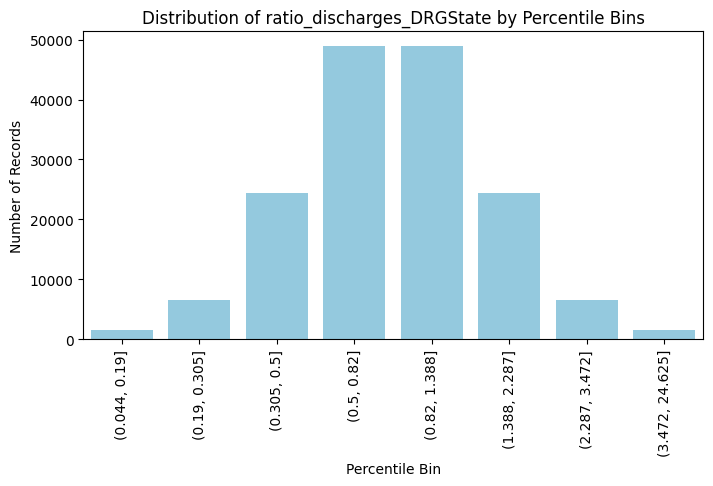

In [91]:
# Define variable for binning
var = 'ratio_discharges_DRGState'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_discharges_DRGState by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [92]:
# Detect potential anomalies
threshold = 3.472
df['Anomaly_ratio_discharges_DRGState'] = (df['ratio_discharges_DRGState'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_discharges_DRGState'].sum()}")

Number of anomalies detected: 1633


In [93]:
# Preview potential anomalies
anomalies_f11 = df[df['Anomaly_ratio_discharges_DRGState'] == 1]
anomalies_f11_table = anomalies_f11[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Total_Discharges',
        'Mean_Total_Discharges_DRGState',
        'ratio_discharges_DRGState'
    ]
]

# Display first few rows
anomalies_f11_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Total_Discharges,Mean_Total_Discharges_DRGState,ratio_discharges_DRGState
8,10039,HUNTSVILLE HOSPITAL,AL,HUNTSVILLE,101 SIVLEY RD,35801,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,135,38.217391,3.532422
394,170186,KANSAS HEART HOSPITAL,KS,WICHITA,3601 NORTH WEBB ROAD,67226,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,190,37.125000,5.117844
440,190263,HEART HOSPITAL OF LAFAYETTE,LA,LAFAYETTE,1105 KALISTE SALOOM ROAD,70508,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,110,29.720000,3.701210


### Feature 12: Ratio of Total Discharges to City-DRG Benchmark (ratio_discharges_DRGCity) <a class="anchor" id="Section_312"></a>

This feature measures how each hospital’s total discharges for a specific DRG compare to the average number of discharges for that same DRG within the same city. Values greater than 1 indicate that a hospital handles more cases than its city peers for the same procedure. This can help identify hospitals with unusually high patient volumes for certain services, potentially signaling local market dominance, specialization, or coding practices worth closer examination.

In [94]:
# Compute mean total discharges by City and DRG (Benchmark)
benchmark_discharges_DRG_City = (
    df.groupby(['Provider_City', 'DRG'], observed=True)['Total_Discharges']
    .mean()
    .reset_index()
    .rename(columns={'Total_Discharges': 'Mean_Total_Discharges_DRGCity'})
)

# Merge benchmark back to the main data
df = df.merge(
    benchmark_discharges_DRG_City,
    on=['Provider_City', 'DRG'],
    how='left'
)

# Preview benchmark table
benchmark_discharges_DRG_City.head(3)

,Provider_City,DRG,Mean_Total_Discharges_DRGCity
0,ABBEVILLE,178 - RESPIRATORY INFECTIONS & INFLAMMATIONS W CC,12.0
1,ABBEVILLE,192 - CHRONIC OBSTRUCTIVE PULMONARY DISEASE W/...,15.0
2,ABBEVILLE,194 - SIMPLE PNEUMONIA & PLEURISY W CC,48.0


In [95]:
# Calculate ratio feature
epsilon = 1e-5  # to avoid division by zero
df['ratio_discharges_DRGCity'] = df['Total_Discharges'] / (
    df['Mean_Total_Discharges_DRGCity'] + epsilon
)

In [96]:
# View descriptive statistics
print(df['ratio_discharges_DRGCity'].describe())

count    163065.000000
mean          1.000000
std           0.356433
min           0.019540
25%           0.920000
50%           1.000000
75%           1.000000
max           5.689303
Name: ratio_discharges_DRGCity, dtype: float64


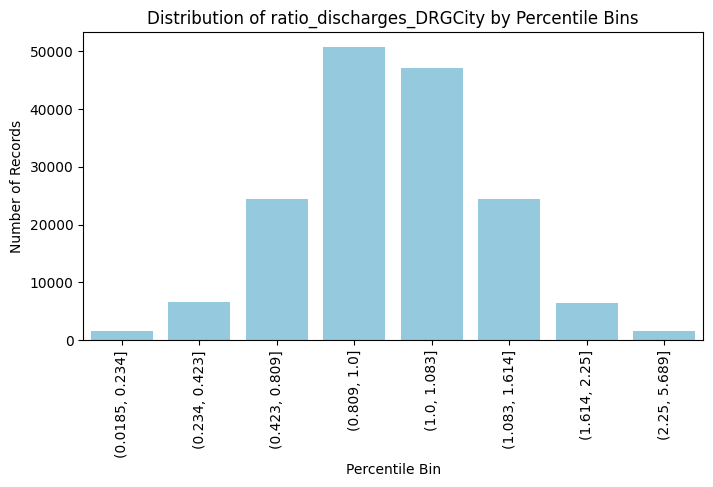

In [97]:
# Define variable for binning
var = 'ratio_discharges_DRGCity'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
df[binned_var] = pd.qcut(df[var], q=percentiles, duplicates='drop')

# Plot distribution by percentiles
plt.figure(figsize=(8,4))
g = sns.countplot(x=binned_var, data=df, color='skyblue')
g.tick_params(axis='x', rotation=90)
plt.title('Distribution of ratio_discharges_DRGCity by Percentile Bins')
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.show()

In [98]:
# Detect potential anomalies
threshold = 2.25
df['Anomaly_ratio_discharges_DRGCity'] = (df['ratio_discharges_DRGCity'] > threshold).astype(int)

print(f"Number of anomalies detected: {df['Anomaly_ratio_discharges_DRGCity'].sum()}")

Number of anomalies detected: 1624


In [99]:
# Preview potential anomalies
anomalies_f12 = df[df['Anomaly_ratio_discharges_DRGCity'] == 1]
anomalies_f12_table = anomalies_f12[
    [
        'Provider_Id',
        'Provider_Name',
        'Provider_State',
        'Provider_City',
        'Provider_StreetAddress',
        'Provider_Zipcode',
        'DRG',
        'Total_Discharges',
        'Mean_Total_Discharges_DRGCity',
        'ratio_discharges_DRGCity'
    ]
]

# Display first few rows
anomalies_f12_table.head(3)

,Provider_Id,Provider_Name,Provider_State,Provider_City,Provider_StreetAddress,Provider_Zipcode,DRG,Total_Discharges,Mean_Total_Discharges_DRGCity,ratio_discharges_DRGCity
394,170186,KANSAS HEART HOSPITAL,KS,WICHITA,3601 NORTH WEBB ROAD,67226,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,190,68.500000,2.773722
440,190263,HEART HOSPITAL OF LAFAYETTE,LA,LAFAYETTE,1105 KALISTE SALOOM ROAD,70508,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,110,42.333333,2.598425
451,210015,FRANKLIN SQUARE HOSPITAL CENTER,MD,BALTIMORE,9000 FRANKLIN SQUARE DR,21237,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,81,32.571429,2.486841


### Summary of the Created Ratio Features <a class="anchor" id="Section_313"></a>

Average Total Payment Features
1. Ratio of average total payment to national DRG benchmark (ratio_avg_paymentDRG)
2. Ratio of average total payment to state benchmark (ratio_avg_paymentState)
3. Ratio of average total payment to city benchmark (ratio_avg_paymentCity)
4. Ratio of average total payment to state-DRG benchmark (ratio_avg_paymentDRGState)
5. Ratio of average total payment to city-DRG benchmark (ratio_avg_paymentDRGCity)
6. Ratio of average Medicare payment to national DRG benchmark (ratio_avg_medicare_paymentDRG)
7. Ratio of average Medicare payment to state benchmark (ratio_avg_medicare_paymentState)
8. Ratio of average Medicare payment to city benchmark (ratio_avg_medicare_paymentCity)
9. Ratio of average Medicare payment to state-DRG benchmark (ratio_avg_medicare_paymentDRGState)
10. Ratio of average Medicare payment to city-DRG benchmark (ratio_avg_medicare_paymentDRGCity)
11. Ratio of total discharges to state-DRG benchmark (ratio_discharges_DRGState)
12. Ratio of total discharges to city-DRG benchmark (ratio_discharges_DRGCity)

In this feature engineering phase, we created 12 ratio-based features to benchmark hospitals’ payments and discharge volumes against national, state, and city norms, capturing potential anomalies across different levels of granularity. These features serve as powerful signals to identify providers whose costs, reimbursements, or patient volumes deviate significantly from typical patterns. In the next two sections, we leverage these engineered features as inputs to the iForest and PCA model to systematically detect outliers and flag hospitals for further investigation.

### 4. Prepare Feature Dataset for Modeling <a class="anchor" id="Section_4"></a>

In [123]:
# Define the feature column names (12 features)
feature_names = [
    'ratio_avg_paymentDRG',
    'ratio_avg_paymentState',
    'ratio_avg_paymentCity',
    'ratio_avg_paymentDRGState',
    'ratio_avg_paymentDRGCity',
    'ratio_avg_medicare_paymentDRG',
    'ratio_avg_medicare_paymentState',
    'ratio_avg_medicare_paymentCity',
    'ratio_avg_medicare_paymentDRGState',
    'ratio_avg_medicare_paymentDRGCity',
    'ratio_discharges_DRGState',
    'ratio_discharges_DRGCity'
]

# Extract the modeling dataset
feature_df = df[feature_names]

# Show shape
print("Shape of modeling dataset:", feature_df.shape)

Shape of modeling dataset: (163065, 12)


In [124]:
# Check for missing values
print(feature_df.isna().sum())

ratio_avg_paymentDRG                  0
ratio_avg_paymentState                0
ratio_avg_paymentCity                 0
ratio_avg_paymentDRGState             0
ratio_avg_paymentDRGCity              0
ratio_avg_medicare_paymentDRG         0
ratio_avg_medicare_paymentState       0
ratio_avg_medicare_paymentCity        0
ratio_avg_medicare_paymentDRGState    0
ratio_avg_medicare_paymentDRGCity     0
ratio_discharges_DRGState             0
ratio_discharges_DRGCity              0
dtype: int64


In [131]:
# Check for 0 values
(feature_df == 0).any()

ratio_avg_paymentDRG                  False
ratio_avg_paymentState                False
ratio_avg_paymentCity                 False
ratio_avg_paymentDRGState             False
ratio_avg_paymentDRGCity              False
ratio_avg_medicare_paymentDRG         False
ratio_avg_medicare_paymentState       False
ratio_avg_medicare_paymentCity        False
ratio_avg_medicare_paymentDRGState    False
ratio_avg_medicare_paymentDRGCity     False
ratio_discharges_DRGState             False
ratio_discharges_DRGCity              False
dtype: bool

In [134]:
# Standardize the data
scaler = StandardScaler()
feature_df_scaled = scaler.fit_transform(feature_df)

# Convert back to DataFrame for readability
feature_df_scaled = pd.DataFrame(feature_df_scaled, columns=feature_names)

# Preview results
feature_df_scaled.head()

,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity
0,-0.684773,-0.310558,-0.431796,0.029983,3.512075e-01,-0.506699,-0.311356,-0.437723,0.165907,3.246413e-01,2.013039,9.489492e-01
1,-0.678795,-0.308767,-0.212674,0.039193,-2.921116e-09,-0.370459,-0.271270,-0.183217,0.381184,-2.291680e-09,-0.923610,-9.513467e-07
2,-0.882857,-0.369911,-0.548752,-0.275205,-1.174777e+00,-0.704963,-0.369691,-0.548030,-0.147376,-9.257353e-01,-0.542227,-1.341802e+00
3,-0.892920,-0.372927,-0.574230,-0.290710,-7.876061e-01,-0.912623,-0.430790,-0.603076,-0.475507,-8.442082e-01,-0.504089,-4.805147e-01
4,-0.753586,-0.331177,-0.386861,-0.076038,-3.287695e-09,-0.450592,-0.294848,-0.338925,0.254563,-2.726213e-09,-0.771057,-5.060160e-07


### 5. Isolation Forest (iForest) <a class="anchor" id="Section_5"></a>

### Step 1: Build the Model <a class="anchor" id="Section_51"></a>

In [148]:
# Split feature_df_scaled into train and test sets (test size = 0.2)
X_train, X_test = train_test_split(
    feature_df_scaled,
    test_size=0.20,
    random_state=123
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (130452, 12)
Test shape: (32613, 12)


In [150]:
# Initialize model
isft = IForest(
    contamination=0.05,
    n_estimators=100,
    max_samples='auto',
    random_state=42
)

# Fit on training data
isft.fit(X_train.values)

# Training data
y_train_scores = isft.decision_function(X_train.values)
y_train_pred = isft.predict(X_train.values)

# Test data
y_test_scores = isft.decision_function(X_test.values)
y_test_pred = isft.predict(X_test.values) # outlier labels (0 or 1)

# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , isft.threshold_)

# Define clean count function
def count_stat(vector):
    unique, counts = np.unique(vector, return_counts=True)
    return {int(k): int(v) for k, v in zip(unique, counts)}

# Print counts
print("Training data:", count_stat(y_train_pred))
print("Test data:", count_stat(y_test_pred))

The threshold for the defined contamination rate: -5.164275176114744e-17
Training data: {0: 123929, 1: 6523}
Test data: {0: 30976, 1: 1637}


In [151]:
# Review important parameters
isft.get_params()

{'behaviour': 'old',
 'bootstrap': False,
 'contamination': 0.05,
 'max_features': 1.0,
 'max_samples': 'auto',
 'n_estimators': 100,
 'n_jobs': 1,
 'random_state': 42,
 'verbose': 0}

In [152]:
# Values of the variable importance
isft_vi = isft.feature_importances_
isft_vi

array([0.08397427, 0.0781348 , 0.0864134 , 0.09206331, 0.07719666,
       0.09879202, 0.08602886, 0.07069029, 0.0795196 , 0.08685606,
       0.07630226, 0.08402845])

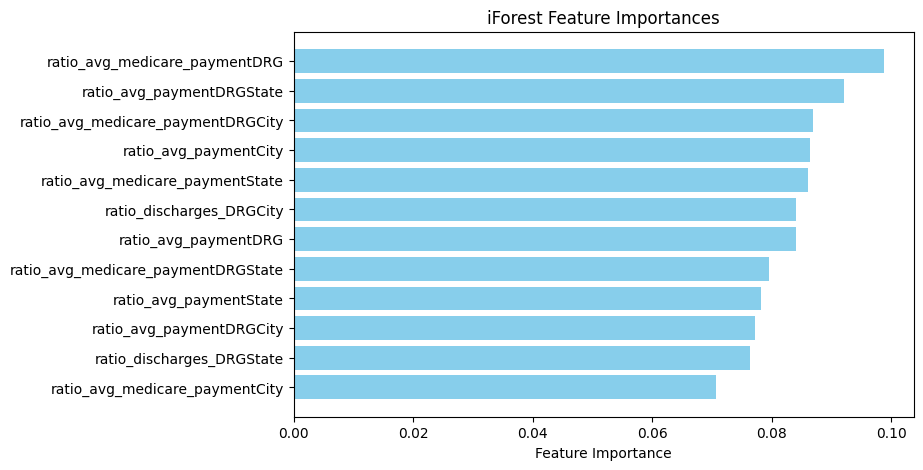

In [160]:
# Visualize variable importance

# Create DataFrame with feature names and importances
X_train_pd = pd.DataFrame(X_train)

for_plot = pd.DataFrame({
    'x_axis': X_train_pd.columns,
    'y_axis': isft.feature_importances_
}).sort_values(by='y_axis', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(for_plot['x_axis'], for_plot['y_axis'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('iForest Feature Importances')
plt.show()

Features with higher importance scores have a greater impact on the splits that isolate outliers, indicating their strong role in distinguishing between normal data points and anomalies.

### Step 2: Determine a Reasonable Threshold for the Model <a class="anchor" id="Section_52"></a>

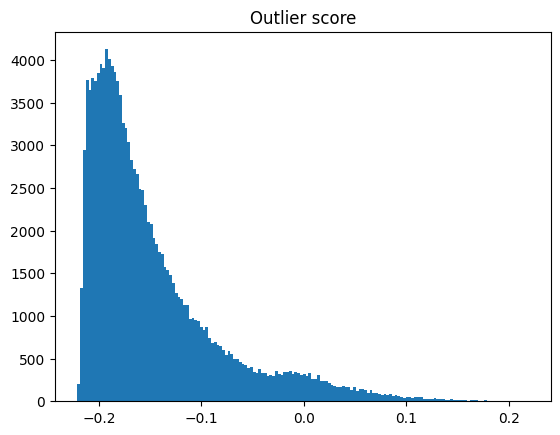

In [161]:
plt.hist(y_train_scores, bins='auto') # arguments are passed to np.histogram
plt.title("Outlier score")
plt.show()

### Step 3: Descriptive Statistics <a class="anchor" id="Section_53"></a>

In [168]:
# Determine the thresold 
threshold = isft.threshold_

feature_list = [
    'ratio_avg_paymentDRG',
    'ratio_avg_paymentState',
    'ratio_avg_paymentCity',
    'ratio_avg_paymentDRGState',
    'ratio_avg_paymentDRGCity',
    'ratio_avg_medicare_paymentDRG',
    'ratio_avg_medicare_paymentState',
    'ratio_avg_medicare_paymentCity',
    'ratio_avg_medicare_paymentDRGState',
    'ratio_avg_medicare_paymentDRGCity',
    'ratio_discharges_DRGState',
    'ratio_discharges_DRGCity'
]

# Function to show the descriptive table
def descriptive_stat_threshold(df, pred_score, threshold):
    # Let's see how many '0's and '1's.
    df = pd.DataFrame(df)
    df.columns = feature_list
    df['Anomaly_Score'] = pred_score
    df['Group'] = np.where(df['Anomaly_Score']< threshold,
                 'Normal', 'Outlier')
    # Now let's show the summary statistics:
    cnt = df.groupby('Group')['Anomaly_Score'].count().reset_index().rename(columns={'Anomaly_Score':'Count'})
    # The count and count %
    cnt['Count %'] = (cnt['Count'] / cnt['Count'].sum()) * 100
    # The average
    stat = df.groupby('Group').mean().round(2).reset_index()
    # Put the count and the average together
    stat = cnt.merge(stat, left_on='Group', right_on='Group')
    return (stat)

In [169]:
# Train data
descriptive_stat_threshold(X_train,y_train_scores, threshold)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,123929,94.999693,-0.10,-0.12,-0.11,-0.1,-0.08,-0.09,-0.12,-0.10,-0.10,-0.08,-0.02,-0.01,-0.16
1,Outlier,6523,5.000307,1.86,2.31,2.01,2.0,1.61,1.77,2.29,1.97,1.92,1.52,0.27,0.14,0.05


In [171]:
# Test data
descriptive_stat_threshold(X_test,y_test_scores, threshold)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,30976,94.980529,-0.10,-0.12,-0.11,-0.10,-0.08,-0.09,-0.12,-0.11,-0.10,-0.08,-0.01,-0.01,-0.16
1,Outlier,1637,5.019471,1.86,2.33,2.04,1.94,1.56,1.77,2.31,2.01,1.85,1.44,0.34,0.27,0.05


In [223]:
def confusion_matrix_threshold(
    actual,score, threshold):
    Actual_pred = pd.DataFrame({'Actual': actual, 'Pred': score})
    Actual_pred['Pred'] = np.where(Actual_pred['Pred']<=threshold,0,1)
    cm = pd.crosstab(Actual_pred['Actual'],Actual_pred['Pred'])
    return (cm)
    
y_train = np.zeros_like(y_train_scores)

# Confusion matrix (train)
confusion_matrix_threshold(y_train,y_train_scores,threshold)

Pred,0,1
Actual,,
0.0,123929,6523


In [222]:
y_test = np.zeros_like(y_test_scores)

# Confusion matrix (test)
confusion_matrix_threshold(y_test,y_test_scores,threshold)

Pred,0,1
Actual,,
0.0,30964,1649


### Step 4: Achieve Model Stability by Aggregating Multiple Models <a class="anchor" id="Section_54"></a>

In [190]:
# Test a range of maximum samples
k_list = [100, 200, 300, 400, 500]
n_clf = len(k_list)

# Prepare arrays to store results
train_scores = np.zeros([X_train.shape[0], n_clf])
test_scores = np.zeros([X_test.shape[0], n_clf])

# Modeling
for i in range(n_clf):
    k = k_list[i]
    isft = IForest(
        contamination=0.05,
        n_estimators=k,
        random_state=42
    )
    isft.fit(X_train.values)
    
    # Store results
    train_scores[:, i] = isft.decision_function(X_train.values)
    test_scores[:, i] = isft.decision_function(X_test.values)

# Standardize
train_scores_norm, test_scores_norm = standardizer(train_scores, test_scores)

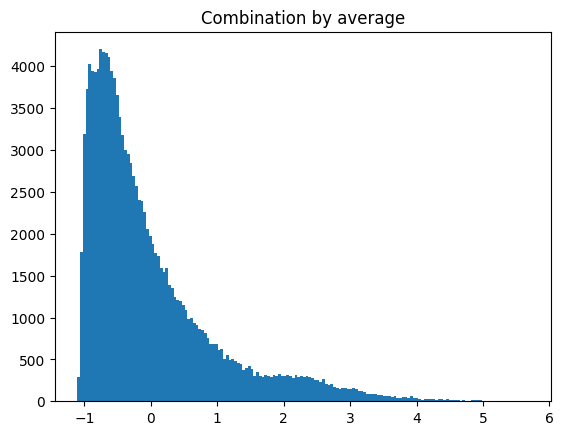

In [191]:
# Combination by average
# The test_scores_norm is 500 x 10. The "average" function will take the average of the 10 columns. The result "y_by_average" is a single column:
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)
import matplotlib.pyplot as plt
plt.hist(y_train_by_average, bins='auto') # arguments are passed to np.histogram
plt.title("Combination by average")
plt.show()

In [207]:
# Train data
descriptive_stat_threshold(X_train,y_train_by_average, 2.23)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,123855,94.942968,-0.09,-0.13,-0.12,-0.10,-0.08,-0.09,-0.13,-0.12,-0.09,-0.07,-0.01,-0.01,-0.16
1,Outlier,6597,5.057032,1.75,2.48,2.21,1.86,1.44,1.67,2.45,2.18,1.78,1.36,0.23,0.12,2.95


In [203]:
# Test data
descriptive_stat_threshold(X_test,y_test_by_average, 2.23)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,30944,94.882409,-0.09,-0.13,-0.12,-0.10,-0.08,-0.09,-0.13,-0.12,-0.09,-0.07,-0.01,-0.01,-0.16
1,Outlier,1669,5.117591,1.74,2.48,2.22,1.78,1.38,1.67,2.48,2.21,1.71,1.27,0.31,0.25,2.95


### Summary of iForest Model <a class="anchor" id="Section_55"></a>

The Isolation Forest (iForest) model was applied to the standardized dataset of 12 engineered ratio-based features, aiming to detect anomalies in hospital cost and payment patterns. The model isolates potential outliers by recursively partitioning the data using random splits and identifying instances that require fewer partitions to become isolated.

Threshold Selection: A threshold of 2.23 was ultimately chosen based on the histogram of combined model scores during aggregation, providing clearer separation between normal and outlier observations.

**Outlier Detection Results**

Training Data (Aggregated iForest Model)
- Normal observations: 123,855 (≈ 94.94%)
- Outliers detected: 6,597 (≈ 5.06%)

Average anomaly scores (Train):
- Normal: -0.16
- Outliers: 2.95
- Outliers showed elevated averages across key features, e.g.:
	- ratio_avg_paymentDRG: from -0.09 in normal hospitals to 1.75 in outliers
	- ratio_avg_paymentState: from -0.13 to 2.48

Test Data (Aggregated iForest Model)
- Normal observations: 30,944 (≈ 94.88%)
- Outliers detected: 1,669 (≈ 5.12%)

Average anomaly scores (Test):
- Normal: -0.16
- Outliers: 2.95
- Outliers showed similar feature shifts:
	- ratio_avg_paymentDRG: from -0.09 to 1.74
	- ratio_avg_paymentState: from -0.13 to 2.48

The iForest model successfully distinguished hospitals with abnormal payment patterns, flagging roughly 5% of records as potential outliers. The ensemble approach enhanced model stability by averaging predictions from multiple iForest configurations, producing more consistent anomaly scores and clearer separation between normal and anomalous cases. Outlier groups consistently displayed substantially higher ratios across multiple cost-related features, indicating potential cases of unusually high charges or reimbursement practices that merit further investigation.

### 6. PCA Analysis <a class="anchor" id="Section_6"></a>

### Step 1: Build the Model <a class="anchor" id="Section_61"></a>

In [209]:
pca = PCA(contamination=0.05)
pca.fit(X_train)

# get the prediction labels and outlier scores of the training data
y_train_pred = pca.labels_  # binary labels (0: inliers, 1: outliers)
y_train_scores = pca.decision_scores_  # .decision_scores_ yields the raw outlier scores for the training data
y_train_scores = pca.decision_function(X_train) 
y_train_pred = pca.predict(X_train) 

y_test_scores = pca.decision_function(X_test) 
y_test_pred = pca.predict(X_test) 

In [210]:
# Review important parameters
pca.get_params()

{'contamination': 0.05,
 'copy': True,
 'iterated_power': 'auto',
 'n_components': None,
 'n_selected_components': None,
 'random_state': None,
 'standardization': True,
 'svd_solver': 'auto',
 'tol': 0.0,
 'weighted': True,
 'whiten': False}

In [211]:
# Proportion of variance explained by a respective principal component
[pca.explained_variance_,
pca.explained_variance_ratio_]

[array([4.88607464e+00, 3.31204730e+00, 1.59618329e+00, 1.10580085e+00,
        4.09643342e-01, 3.39324709e-01, 2.32560264e-01, 5.32451832e-02,
        5.08915605e-02, 9.40253085e-03, 4.38182938e-03, 5.36492800e-04]),
 array([4.07169765e-01, 2.76001826e-01, 1.33014255e-01, 9.21493643e-02,
        3.41366835e-02, 2.82768423e-02, 1.93798734e-02, 4.43706458e-03,
        4.24093086e-03, 7.83538231e-04, 3.65149649e-04, 4.47073906e-05])]

In [229]:
# Extract variance ratios from your PCA object
explained_variance_ratio = pca.explained_variance_ratio_

# Prepare dataframe for plotting
pca_proportion = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Variance Explained (%)': explained_variance_ratio * 100
})

# View the Pca table
pca_proportion

,Principal Component,Variance Explained (%)
0,PC1,40.716977
1,PC2,27.600183
2,PC3,13.301425
3,PC4,9.214936
4,PC5,3.413668
5,PC6,2.827684
6,PC7,1.937987
7,PC8,0.443706
8,PC9,0.424093
9,PC10,0.078354


The table summarizes how much variance each principal component explains in the standardized dataset. The first few components (PC1 to PC4) capture the majority of the variance, with PC1 alone explaining about 40.7%. In contrast, PCs 10 to 12 contribute negligibly, suggesting they carry little useful information for further analysis like anomaly detection.

### Step 2: Determine the Threshold <a class="anchor" id="Section_62"></a>

In [214]:
print("The threshold for the defined contamination rate:" , pca.threshold_)

The threshold for the defined contamination rate: 191865.99972671678


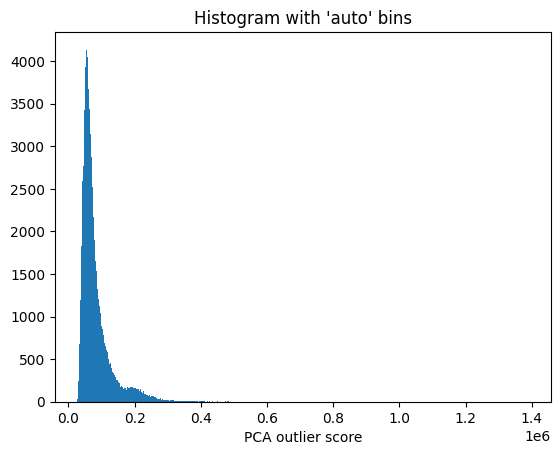

In [215]:
plt.hist(y_train_scores, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")
plt.xlabel('PCA outlier score')
plt.show()

### Step 3: Descriptive Statistics <a class="anchor" id="Section_63"></a>

In [235]:
# Determine the thresold 
threshold = pca.threshold_

feature_list = [
    'ratio_avg_paymentDRG',
    'ratio_avg_paymentState',
    'ratio_avg_paymentCity',
    'ratio_avg_paymentDRGState',
    'ratio_avg_paymentDRGCity',
    'ratio_avg_medicare_paymentDRG',
    'ratio_avg_medicare_paymentState',
    'ratio_avg_medicare_paymentCity',
    'ratio_avg_medicare_paymentDRGState',
    'ratio_avg_medicare_paymentDRGCity',
    'ratio_discharges_DRGState',
    'ratio_discharges_DRGCity'
]

In [240]:
# Train data
descriptive_stat_threshold(X_train,y_train_scores, threshold)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,123929,94.999693,-0.08,-0.13,-0.12,-0.09,-0.07,-0.08,-0.13,-0.12,-0.09,-0.07,-0.02,-0.02,74330.25
1,Outlier,6523,5.000307,1.58,2.50,2.31,1.69,1.34,1.52,2.49,2.28,1.63,1.29,0.43,0.32,247154.24


In [241]:
# Test data
descriptive_stat_threshold(X_test,y_test_scores, threshold)

,Group,Count,Count %,ratio_avg_paymentDRG,ratio_avg_paymentState,ratio_avg_paymentCity,ratio_avg_paymentDRGState,ratio_avg_paymentDRGCity,ratio_avg_medicare_paymentDRG,ratio_avg_medicare_paymentState,ratio_avg_medicare_paymentCity,ratio_avg_medicare_paymentDRGState,ratio_avg_medicare_paymentDRGCity,ratio_discharges_DRGState,ratio_discharges_DRGCity,Anomaly_Score
0,Normal,30964,94.943734,-0.08,-0.13,-0.12,-0.09,-0.07,-0.08,-0.13,-0.12,-0.09,-0.07,-0.02,-0.02,74398.80
1,Outlier,1649,5.056266,1.60,2.47,2.28,1.65,1.30,1.54,2.47,2.28,1.58,1.22,0.51,0.43,247288.48


In [224]:
# Confusion matrix (train)
confusion_matrix_threshold(y_train,y_train_scores,threshold)

Pred,0,1
Actual,,
0.0,123929,6523


In [225]:
# Confusion matrix (test)
confusion_matrix_threshold(y_test,y_test_scores,pca.threshold_)

Pred,0,1
Actual,,
0.0,30964,1649


### Summary of PCA Analysis <a class="anchor" id="Section_64"></a>

In this analysis, we applied PCA-based anomaly detection to the healthcare dataset with a contamination rate of 5%. The model was fitted on the standardized training data, and the decision scores and predictions were computed for both train and test sets.

**Variance Explained**

The PCA decomposition revealed that:
- The first few principal components (PC1 to PC4) captured the majority of the variance (cumulatively ~90%).
- PCs 10–12 explained negligible variance (all < 0.1%), indicating they contain little useful information for anomaly detection.

**Threshold**

The threshold automatically set by the PCA model for separating inliers and outliers was approximately 191,866. This threshold is derived from the distribution of reconstruction errors (anomaly scores) to isolate roughly 5% of points as anomalies.

**Anomaly Scores**

The anomaly scores (shown in the histogram and descriptive statistics) were quite large in absolute value (e.g., ~74,000 for normal points, and up to ~247,000 for outliers). This happens because PCA calculates squared reconstruction errors.

**Detection Results**

Training Data:
- Normal: 123,929 (~95%), anomaly score: 74330.25
- Outliers: 6,523 (~5%), anomaly score: 247154.24

Test Data:
- Normal: 30,964 (~94.94%), anomaly score: 74398.80
- Outliers: 1,649 (~5.06%), anomaly score: 247288.48

Outliers in the PCA results consistently exhibited much higher reconstruction errors than normal observations, confirming PCA’s ability to separate potential anomalies.

### 7. Comparisons between models <a class="anchor" id="Section_7"></a>

In our previous assignment, we used Histogram-Based Outlier Score (HBOS) and Empirical Copula Outlier Detection (ECOD) to detect anomalies in credit card transactions, demonstrating their ability to flag rare, suspicious patterns. Building on that work, we now apply HBOS, ECOD, and Principal Component Analysis (PCA) to our healthcare dataset, which includes ratio-based features capturing hospital payment and discharge behaviors. This section compares these three models to assess their consistency, differences in anomaly detection, and overall effectiveness for identifying potential outliers in healthcare cost data.

In [236]:
#######
# HBOS #
########
from pyod.models.hbos import HBOS
n_bins = 50
hbos = HBOS(n_bins=n_bins,contamination=0.05)
hbos.fit(X_train)
y_train_hbos_scores = hbos.decision_function(X_train)
y_test_hbos_scores = hbos.decision_function(X_test)

########
# ECOD #
########
from pyod.models.ecod import ECOD
clf_name = 'ECOD'
ecod = ECOD(contamination=0.05)
ecod.fit(X_train)
y_train_ecod_scores = ecod.decision_function(X_train)

########
# PCA  #
########
from pyod.models.pca import PCA
pca = PCA(contamination=0.05)
pca.fit(X_train)

# get the prediction labels and outlier scores of the training data
y_train_pca_scores = pca.decision_function(X_train) # You also can use .decision_function()

# Thresholds
[ecod.threshold_, hbos.threshold_, pca.threshold_]

[np.float64(32.68566669318375),
 np.float64(24.119542978618686),
 np.float64(191865.99972671678)]

In [237]:
# Put the actual, the HBO score and the ECOD score together
Actual_preds = pd.DataFrame({'Actual': y_train,
                             'HBO_Score': y_train_hbos_scores,
                             'ECOD_Score': y_train_ecod_scores,
                             'PCA_Score': y_train_pca_scores})
Actual_preds['HBOS_pred'] = np.where(Actual_preds['HBO_Score']>hbos.threshold_,1,0)
Actual_preds['ECOD_pred'] = np.where(Actual_preds['ECOD_Score']>ecod.threshold_,1,0)
Actual_preds['PCA_pred'] = np.where(Actual_preds['PCA_Score']>pca.threshold_,1,0)
Actual_preds.head()

,Actual,HBO_Score,ECOD_Score,PCA_Score,HBOS_pred,ECOD_pred,PCA_pred
0,0.0,3.681601,11.637275,39342.114698,0,0,0
1,0.0,27.180933,30.376426,157395.897895,1,0,0
2,0.0,12.242224,22.710188,91521.605749,0,0,0
3,0.0,19.772608,19.624888,76525.838233,0,0,0
4,0.0,3.614444,20.114680,63984.538765,0,0,0


In [238]:
pd.crosstab(Actual_preds['HBOS_pred'],Actual_preds['PCA_pred'])

PCA_pred,0,1
HBOS_pred,,
0,120333,3596
1,3596,2927


In [239]:
pd.crosstab(Actual_preds['ECOD_pred'],Actual_preds['PCA_pred'])

PCA_pred,0,1
ECOD_pred,,
0,120909,3020
1,3020,3503


### Summary of Model Comparison Results <a class="anchor" id="Section_71"></a>

The comparison of HBOS, ECOD, and PCA models on the healthcare dataset revealed both overlapping and distinct anomaly detection patterns:

HBOS vs. PCA:
- 120,333 observations were classified as normal by both models.
- 2,927 observations were jointly identified as outliers.
- Disagreement occurred for 3,596 observations where HBOS flagged an outlier but PCA did not, and vice versa.
  
ECOD vs. PCA:
- 120,909 observations were labeled as normal by both ECOD and PCA.
- 3,503 observations were jointly flagged as outliers.
- 3,020 observations were outliers in ECOD but not PCA, and vice versa.

For those distinct detected anomalies, it also normal that for instance, PCA might classify a hospital’s costs as normal based on overall variance structure, while HBOS flags it as an outlier due to high payments in certain bins.

Overall, there is strong alignment between the three models in labeling the majority of data as normal, but differences emerge in the specific points classified as outliers. These variations highlight the unique sensitivities of each method. HBOS and ECOD appear slightly more similar to each other than to PCA, which detected a distinct subset of outliers. This suggests that using multiple models provides a more comprehensive perspective on potential anomalies in hospital payment and discharge patterns.